In [1]:
import sys
print(sys.executable)

C:\Users\Jothi M\AppData\Local\Programs\Python\Python314\python.exe


In [2]:
# ================================================
# Project 3 - Financial News Sentiment Analysis
# Author: Jothi | Data Science Portfolio 2026
# ================================================

import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ================================================
# STEP 1 - LOAD DATA
# ================================================

# Load the dataset
df = pd.read_csv('all-data.csv', 
                  encoding='latin-1', 
                  header=None)

# Give proper column names
df.columns = ['sentiment', 'news_headline']

# Check the data
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nSentiment distribution:")
print(df['sentiment'].value_counts())

Shape of dataset: (4846, 2)

First 5 rows:
  sentiment                                      news_headline
0   neutral  According to Gran , the company has no plans t...
1   neutral  Technopolis plans to develop in stages an area...
2  negative  The international electronic industry company ...
3  positive  With the new production plant the company woul...
4  positive  According to the company 's updated strategy f...

Sentiment distribution:
sentiment
neutral     2879
positive    1363
negative     604
Name: count, dtype: int64


In [4]:
# ================================================
# STEP 2 - DATA CLEANING
# ================================================

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicate rows:", df.duplicated().sum())

# Remove duplicates if any
df = df.drop_duplicates()

# Reset index after dropping
df = df.reset_index(drop=True)

# Clean text - remove extra spaces
df['news_headline'] = df['news_headline'].str.strip()

# Check final shape
print("\nShape after cleaning:", df.shape)
print("\nSentiment distribution after cleaning:")
print(df['sentiment'].value_counts())

Missing values:
sentiment        0
news_headline    0
dtype: int64

Duplicate rows: 6

Shape after cleaning: (4840, 2)

Sentiment distribution after cleaning:
sentiment
neutral     2873
positive    1363
negative     604
Name: count, dtype: int64


In [5]:
# ================================================
# STEP 3 - SENTIMENT SCORING WITH VADER
# ================================================

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to get sentiment score
def get_sentiment_score(text):
    score = analyzer.polarity_scores(text)
    return score['compound']  # compound score ranges from -1 to +1

# Function to get VADER predicted sentiment
def get_vader_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply both functions to every headline
df['vader_score'] = df['news_headline'].apply(get_sentiment_score)
df['vader_sentiment'] = df['news_headline'].apply(get_vader_sentiment)

# Show results
print("First 5 rows with scores:")
print(df.head())
print("\nVADER predicted distribution:")
print(df['vader_sentiment'].value_counts())

First 5 rows with scores:
  sentiment                                      news_headline  vader_score  \
0   neutral  According to Gran , the company has no plans t...      -0.1280   
1   neutral  Technopolis plans to develop in stages an area...      -0.2960   
2  negative  The international electronic industry company ...       0.0000   
3  positive  With the new production plant the company woul...       0.8555   
4  positive  According to the company 's updated strategy f...       0.6705   

  vader_sentiment  
0        negative  
1        negative  
2         neutral  
3        positive  
4        positive  

VADER predicted distribution:
vader_sentiment
positive    2395
neutral     2004
negative     441
Name: count, dtype: int64


In [7]:
# ================================================
# STEP 4 - CHECK VADER ACCURACY
# ================================================

from sklearn.metrics import accuracy_score, classification_report

# Compare VADER predictions vs actual labels
accuracy = accuracy_score(df['sentiment'], df['vader_sentiment'])
print(f"VADER Accuracy: {accuracy:.2%}")

print("\nDetailed Classification Report:")
print(classification_report(df['sentiment'], df['vader_sentiment']))

VADER Accuracy: 54.38%

Detailed Classification Report:
              precision    recall  f1-score   support

    negative       0.41      0.30      0.34       604
     neutral       0.74      0.52      0.61      2873
    positive       0.40      0.71      0.51      1363

    accuracy                           0.54      4840
   macro avg       0.52      0.51      0.49      4840
weighted avg       0.61      0.54      0.55      4840



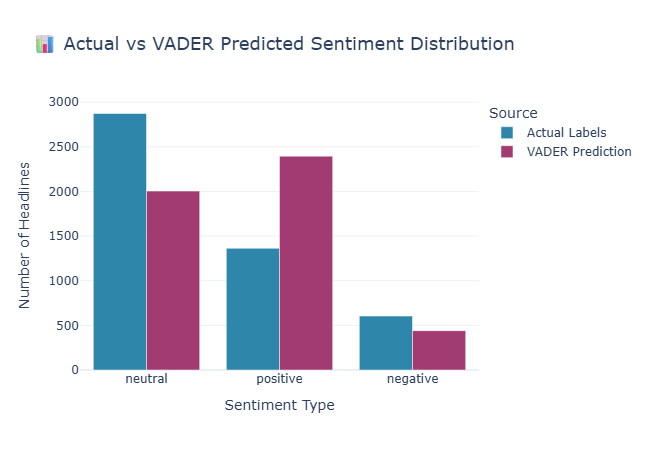

In [8]:
# ================================================
# STEP 5 - VISUALIZATION 1
# Actual vs VADER Sentiment Distribution
# ================================================

# Create comparison dataframe
actual_counts = df['sentiment'].value_counts().reset_index()
actual_counts.columns = ['sentiment', 'count']
actual_counts['type'] = 'Actual Labels'

vader_counts = df['vader_sentiment'].value_counts().reset_index()
vader_counts.columns = ['sentiment', 'count']
vader_counts['type'] = 'VADER Prediction'

# Combine both
combined = pd.concat([actual_counts, vader_counts])

# Create grouped bar chart
fig1 = px.bar(
    combined,
    x='sentiment',
    y='count',
    color='type',
    barmode='group',
    title='📊 Actual vs VADER Predicted Sentiment Distribution',
    color_discrete_map={
        'Actual Labels': '#2E86AB',
        'VADER Prediction': '#A23B72'
    },
    labels={'count': 'Number of Headlines', 
            'sentiment': 'Sentiment Type'},
    template='plotly_white'
)

fig1.update_layout(
    title_font_size=18,
    legend_title='Source',
    height=450
)

fig1.show()

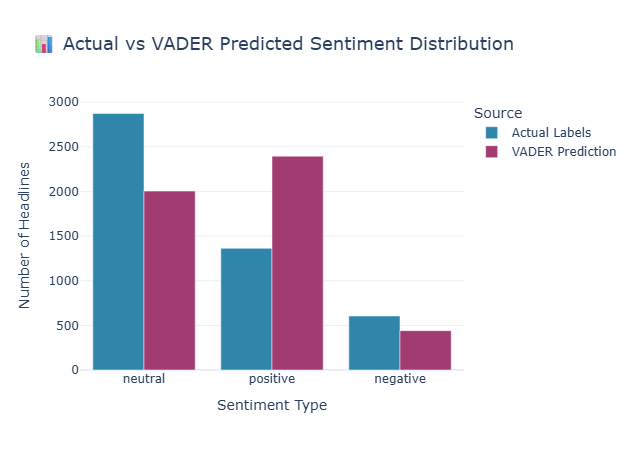

In [9]:
# ================================================
# STEP 5 - VISUALIZATION 1
# Actual vs VADER Sentiment Distribution
# ================================================

# Create comparison dataframe
actual_counts = df['sentiment'].value_counts().reset_index()
actual_counts.columns = ['sentiment', 'count']
actual_counts['type'] = 'Actual Labels'

vader_counts = df['vader_sentiment'].value_counts().reset_index()
vader_counts.columns = ['sentiment', 'count']
vader_counts['type'] = 'VADER Prediction'

# Combine both
combined = pd.concat([actual_counts, vader_counts])

# Create grouped bar chart
fig1 = px.bar(
    combined,
    x='sentiment',
    y='count',
    color='type',
    barmode='group',
    title='📊 Actual vs VADER Predicted Sentiment Distribution',
    color_discrete_map={
        'Actual Labels': '#2E86AB',
        'VADER Prediction': '#A23B72'
    },
    labels={'count': 'Number of Headlines', 
            'sentiment': 'Sentiment Type'},
    template='plotly_white'
)

fig1.update_layout(
    title_font_size=18,
    legend_title='Source',
    height=450
)

fig1.show()

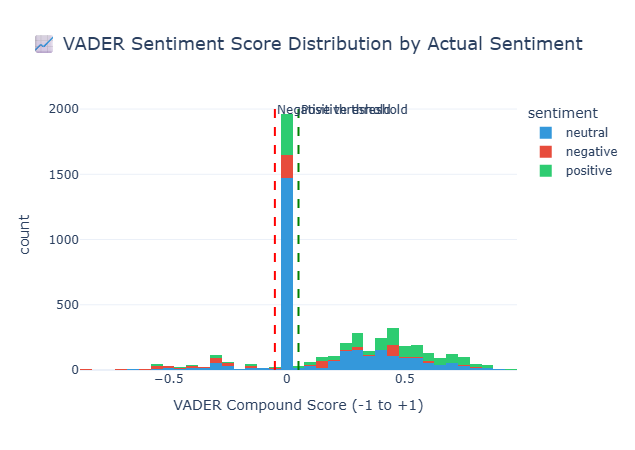

In [10]:
# ================================================
# STEP 6 - VISUALIZATION 2
# Sentiment Score Distribution
# ================================================

# Create histogram of VADER compound scores
fig2 = px.histogram(
    df,
    x='vader_score',
    color='sentiment',
    title='📈 VADER Sentiment Score Distribution by Actual Sentiment',
    nbins=50,
    color_discrete_map={
        'positive': '#2ECC71',
        'negative': '#E74C3C',
        'neutral': '#3498DB'
    },
    labels={
        'vader_score': 'VADER Compound Score (-1 to +1)',
        'count': 'Number of Headlines'
    },
    template='plotly_white'
)

fig2.add_vline(
    x=0.05, 
    line_dash='dash', 
    line_color='green',
    annotation_text='Positive threshold'
)

fig2.add_vline(
    x=-0.05, 
    line_dash='dash', 
    line_color='red',
    annotation_text='Negative threshold'
)

fig2.update_layout(
    title_font_size=18,
    height=450
)

fig2.show()

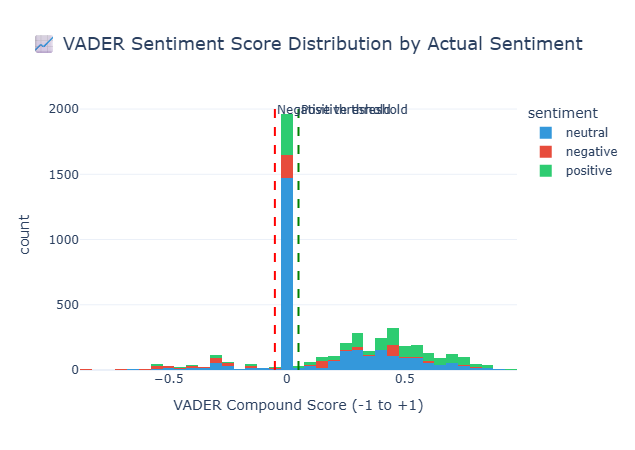

In [11]:
# ================================================
# STEP 6 - VISUALIZATION 2
# Sentiment Score Distribution
# ================================================

# Create histogram of VADER compound scores
fig2 = px.histogram(
    df,
    x='vader_score',
    color='sentiment',
    title='📈 VADER Sentiment Score Distribution by Actual Sentiment',
    nbins=50,
    color_discrete_map={
        'positive': '#2ECC71',
        'negative': '#E74C3C',
        'neutral': '#3498DB'
    },
    labels={
        'vader_score': 'VADER Compound Score (-1 to +1)',
        'count': 'Number of Headlines'
    },
    template='plotly_white'
)

fig2.add_vline(
    x=0.05, 
    line_dash='dash', 
    line_color='green',
    annotation_text='Positive threshold'
)

fig2.add_vline(
    x=-0.05, 
    line_dash='dash', 
    line_color='red',
    annotation_text='Negative threshold'
)

fig2.update_layout(
    title_font_size=18,
    height=450
)

fig2.show()

Average VADER scores by sentiment:
  sentiment  avg_score  std_score
0  negative   0.028885   0.331758
1   neutral   0.152062   0.267114
2  positive   0.325306   0.301596


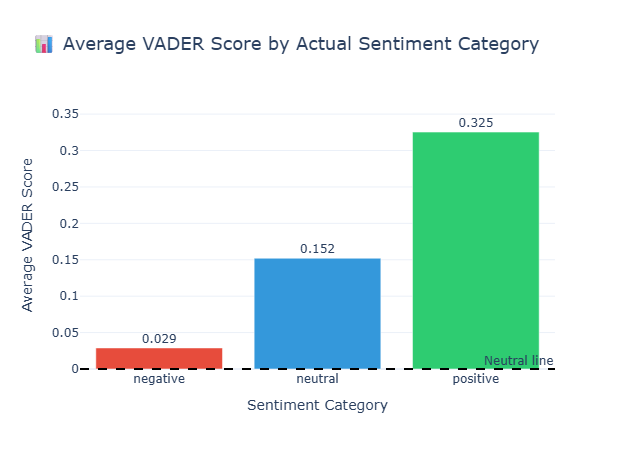

In [12]:
# ================================================
# STEP 7 - VISUALIZATION 3
# Average Sentiment Score by Category
# ================================================

# Calculate average VADER score per sentiment category
avg_scores = df.groupby('sentiment')['vader_score'].agg(['mean', 'std']).reset_index()
avg_scores.columns = ['sentiment', 'avg_score', 'std_score']

print("Average VADER scores by sentiment:")
print(avg_scores)

# Create bar chart
fig3 = px.bar(
    avg_scores,
    x='sentiment',
    y='avg_score',
    color='sentiment',
    title='📊 Average VADER Score by Actual Sentiment Category',
    color_discrete_map={
        'positive': '#2ECC71',
        'negative': '#E74C3C',
        'neutral': '#3498DB'
    },
    labels={
        'avg_score': 'Average VADER Score',
        'sentiment': 'Sentiment Category'
    },
    template='plotly_white',
    text='avg_score'
)

fig3.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig3.update_layout(
    title_font_size=18,
    showlegend=False,
    height=450
)

fig3.add_hline(
    y=0,
    line_dash='dash',
    line_color='black',
    annotation_text='Neutral line'
)

fig3.show()

Average VADER scores by sentiment:
  sentiment  avg_score  std_score
0  negative   0.028885   0.331758
1   neutral   0.152062   0.267114
2  positive   0.325306   0.301596


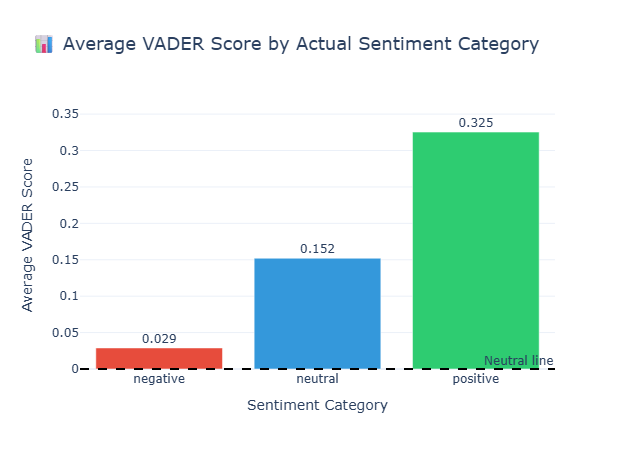

In [13]:
# ================================================
# STEP 7 - VISUALIZATION 3
# Average Sentiment Score by Category
# ================================================

# Calculate average VADER score per sentiment category
avg_scores = df.groupby('sentiment')['vader_score'].agg(['mean', 'std']).reset_index()
avg_scores.columns = ['sentiment', 'avg_score', 'std_score']

print("Average VADER scores by sentiment:")
print(avg_scores)

# Create bar chart
fig3 = px.bar(
    avg_scores,
    x='sentiment',
    y='avg_score',
    color='sentiment',
    title='📊 Average VADER Score by Actual Sentiment Category',
    color_discrete_map={
        'positive': '#2ECC71',
        'negative': '#E74C3C',
        'neutral': '#3498DB'
    },
    labels={
        'avg_score': 'Average VADER Score',
        'sentiment': 'Sentiment Category'
    },
    template='plotly_white',
    text='avg_score'
)

fig3.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig3.update_layout(
    title_font_size=18,
    showlegend=False,
    height=450
)

fig3.add_hline(
    y=0,
    line_dash='dash',
    line_color='black',
    annotation_text='Neutral line'
)

fig3.show()

Average VADER scores by sentiment:
  sentiment  avg_score  std_score
0  negative   0.028885   0.331758
1   neutral   0.152062   0.267114
2  positive   0.325306   0.301596


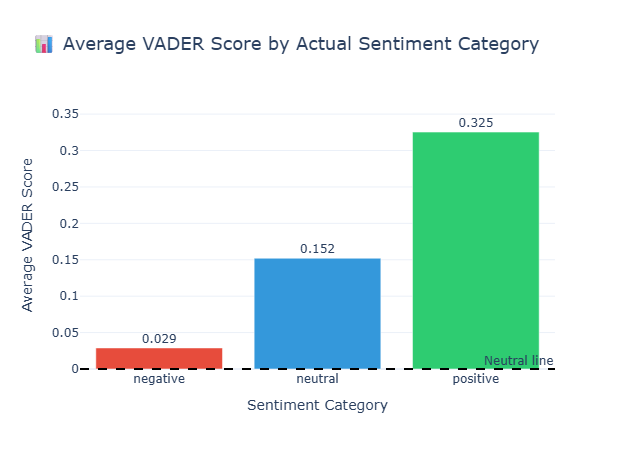

In [14]:
# ================================================
# STEP 7 - VISUALIZATION 3
# Average Sentiment Score by Category
# ================================================

# Calculate average VADER score per sentiment category
avg_scores = df.groupby('sentiment')['vader_score'].agg(['mean', 'std']).reset_index()
avg_scores.columns = ['sentiment', 'avg_score', 'std_score']

print("Average VADER scores by sentiment:")
print(avg_scores)

# Create bar chart
fig3 = px.bar(
    avg_scores,
    x='sentiment',
    y='avg_score',
    color='sentiment',
    title='📊 Average VADER Score by Actual Sentiment Category',
    color_discrete_map={
        'positive': '#2ECC71',
        'negative': '#E74C3C',
        'neutral': '#3498DB'
    },
    labels={
        'avg_score': 'Average VADER Score',
        'sentiment': 'Sentiment Category'
    },
    template='plotly_white',
    text='avg_score'
)

fig3.update_traces(
    texttemplate='%{text:.3f}',
    textposition='outside'
)

fig3.update_layout(
    title_font_size=18,
    showlegend=False,
    height=450
)

fig3.add_hline(
    y=0,
    line_dash='dash',
    line_color='black',
    annotation_text='Neutral line'
)

fig3.show()

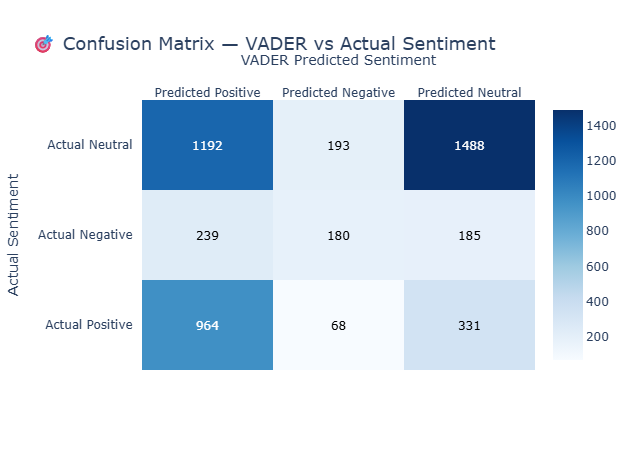

In [15]:
# ================================================
# STEP 8 - VISUALIZATION 4
# Confusion Matrix - VADER vs Actual
# ================================================

from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff

# Create confusion matrix
cm = confusion_matrix(
    df['sentiment'], 
    df['vader_sentiment'],
    labels=['positive', 'negative', 'neutral']
)

# Create heatmap
fig4 = ff.create_annotated_heatmap(
    z=cm,
    x=['Predicted Positive', 'Predicted Negative', 'Predicted Neutral'],
    y=['Actual Positive', 'Actual Negative', 'Actual Neutral'],
    colorscale='Blues',
    showscale=True
)

fig4.update_layout(
    title='🎯 Confusion Matrix — VADER vs Actual Sentiment',
    title_font_size=18,
    height=450,
    xaxis_title='VADER Predicted Sentiment',
    yaxis_title='Actual Sentiment'
)

fig4.show()

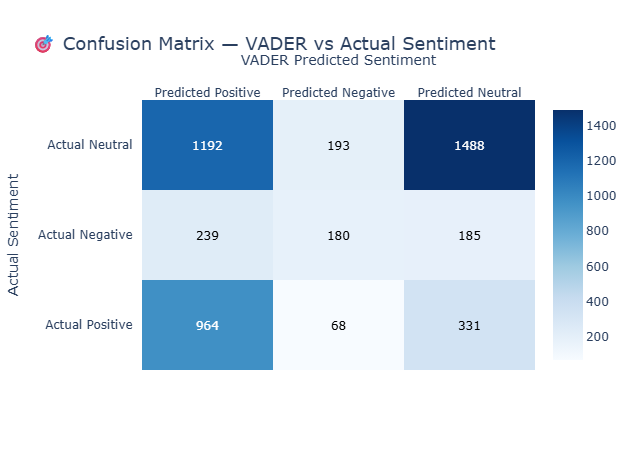

In [16]:
# ================================================
# STEP 8 - VISUALIZATION 4
# Confusion Matrix - VADER vs Actual
# ================================================

from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff

# Create confusion matrix
cm = confusion_matrix(
    df['sentiment'], 
    df['vader_sentiment'],
    labels=['positive', 'negative', 'neutral']
)

# Create heatmap
fig4 = ff.create_annotated_heatmap(
    z=cm,
    x=['Predicted Positive', 'Predicted Negative', 'Predicted Neutral'],
    y=['Actual Positive', 'Actual Negative', 'Actual Neutral'],
    colorscale='Blues',
    showscale=True
)

fig4.update_layout(
    title='🎯 Confusion Matrix — VADER vs Actual Sentiment',
    title_font_size=18,
    height=450,
    xaxis_title='VADER Predicted Sentiment',
    yaxis_title='Actual Sentiment'
)

fig4.show()

TOP 10 MOST POSITIVE HEADLINES:
Score: 0.946 | Tieto was looking for an energy solution which would best support the idea of su
Score: 0.940 | efficiency improvement measures 20 January 2010 - Finnish stationery and gift re
Score: 0.936 | The long-standing partnership and commitment enable both parties to develop thei
Score: 0.913 | The restructuring creates a more efficient organization with increased operation
Score: 0.878 | Luxembourg-registered investment fund Amber Trust II has won the final approval 
Score: 0.875 | Metrics in QPR ScoreCard now support date , text and milestone-based values , wh
Score: 0.874 | We can choose the most efficient , best overall value option for our customers a
Score: 0.872 | Thanks to his wide contact network and good knowledge of market and business env
Score: 0.866 | The seminar introduced modern , clean technologies and products , financial tool
Score: 0.866 | In a release , the Company said that Vocollect T2 customers in North America can

TOP 10 

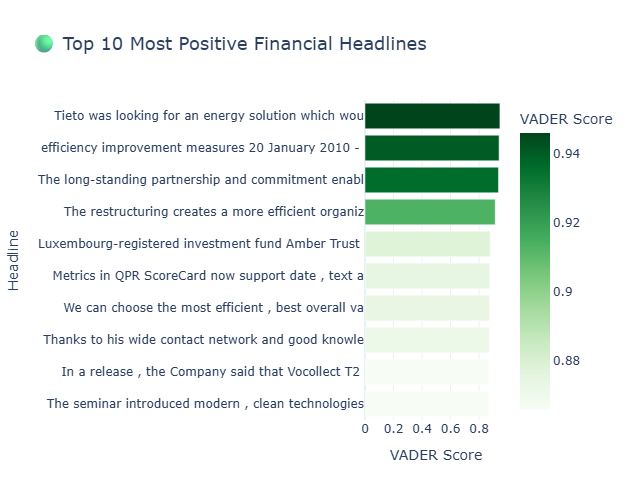

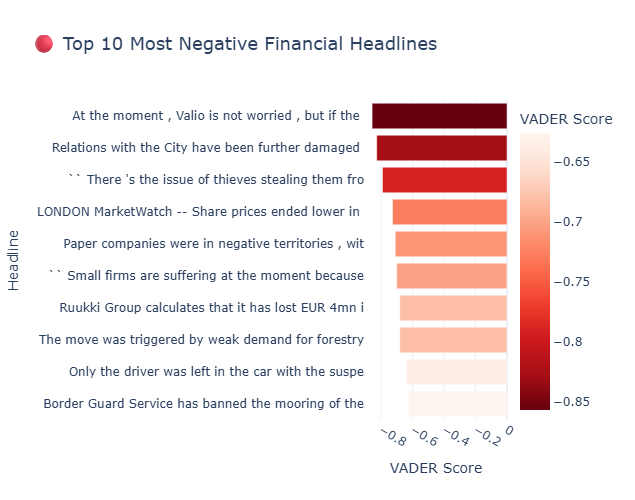

In [17]:
# ================================================
# STEP 9 - VISUALIZATION 5
# Top 10 Most Positive & Negative Headlines
# ================================================

# Get top 10 most positive headlines
top_positive = df[df['sentiment'] == 'positive'].nlargest(10, 'vader_score')[['news_headline', 'vader_score']]

# Get top 10 most negative headlines
top_negative = df[df['sentiment'] == 'negative'].nsmallest(10, 'vader_score')[['news_headline', 'vader_score']]

print("TOP 10 MOST POSITIVE HEADLINES:")
print("="*60)
for i, row in top_positive.iterrows():
    print(f"Score: {row['vader_score']:.3f} | {row['news_headline'][:80]}")

print("\nTOP 10 MOST NEGATIVE HEADLINES:")
print("="*60)
for i, row in top_negative.iterrows():
    print(f"Score: {row['vader_score']:.3f} | {row['news_headline'][:80]}")

# Visualize top positive
fig5 = px.bar(
    top_positive,
    x='vader_score',
    y=top_positive['news_headline'].str[:50],
    orientation='h',
    title='🟢 Top 10 Most Positive Financial Headlines',
    color='vader_score',
    color_continuous_scale='Greens',
    labels={'vader_score': 'VADER Score', 'y': 'Headline'},
    template='plotly_white'
)

fig5.update_layout(
    title_font_size=18,
    height=500,
    yaxis={'categoryorder': 'total ascending'}
)

fig5.show()

# Visualize top negative
fig6 = px.bar(
    top_negative,
    x='vader_score',
    y=top_negative['news_headline'].str[:50],
    orientation='h',
    title='🔴 Top 10 Most Negative Financial Headlines',
    color='vader_score',
    color_continuous_scale='Reds_r',
    labels={'vader_score': 'VADER Score', 'y': 'Headline'},
    template='plotly_white'
)

fig6.update_layout(
    title_font_size=18,
    height=500,
    yaxis={'categoryorder': 'total descending'}
)

fig6.show()

In [23]:
print(df.columns.tolist())
print(df.head())


['sentiment', 'news_headline', 'vader_score', 'vader_sentiment']
  sentiment                                      news_headline  vader_score  \
0   neutral  According to Gran , the company has no plans t...      -0.1280   
1   neutral  Technopolis plans to develop in stages an area...      -0.2960   
2  negative  The international electronic industry company ...       0.0000   
3  positive  With the new production plant the company woul...       0.8555   
4  positive  According to the company 's updated strategy f...       0.6705   

  vader_sentiment  
0        negative  
1        negative  
2         neutral  
3        positive  
4        positive  


2026-03-26 11:44:00.883 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 11:44:01.371 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 11:44:01.741 
  command:

    streamlit run C:\Users\Jothi M\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-26 11:44:01.742 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 11:44:01.745 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 11:44:02.230 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 11:44:02.476 Thread 'MainThread': missing ScriptRunContext! This 

DeltaGenerator()

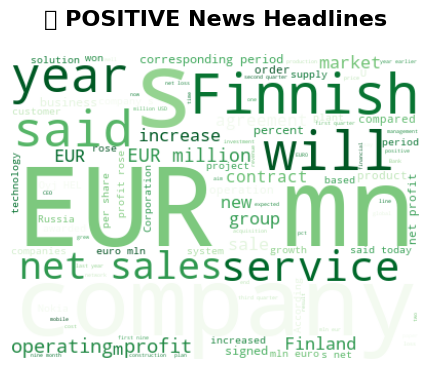

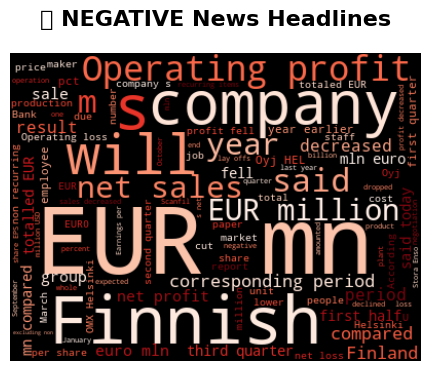

In [24]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import streamlit as st

# POSITIVE WORDCLOUD
positive_text = ' '.join(df[df['sentiment'] == 'positive']['news_headline'].dropna())
wordcloud_pos = WordCloud(width=400, height=300, background_color='white', 
                         colormap='Greens', max_words=100).generate(positive_text)

fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.imshow(wordcloud_pos, interpolation='bilinear')
ax1.set_title('🟢 POSITIVE News Headlines', fontsize=16, fontweight='bold', pad=20)
ax1.axis('off')
st.pyplot(fig1)

# NEGATIVE WORDCLOUD
negative_text = ' '.join(df[df['sentiment'] == 'negative']['news_headline'].dropna())
wordcloud_neg = WordCloud(width=400, height=300, background_color='black', 
                         colormap='Reds', max_words=100).generate(negative_text)

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.imshow(wordcloud_neg, interpolation='bilinear')
ax2.set_title('🔴 NEGATIVE News Headlines', fontsize=16, fontweight='bold', pad=20)
ax2.axis('off')
st.pyplot(fig2)


In [18]:
# ================================================
# STEP 10 - BUSINESS INSIGHTS SUMMARY
# ================================================

# Calculate key metrics
total = len(df)
positive_pct = (df['sentiment'] == 'positive').sum() / total * 100
negative_pct = (df['sentiment'] == 'negative').sum() / total * 100
neutral_pct = (df['sentiment'] == 'neutral').sum() / total * 100

avg_positive_score = df[df['sentiment'] == 'positive']['vader_score'].mean()
avg_negative_score = df[df['sentiment'] == 'negative']['vader_score'].mean()
avg_neutral_score = df[df['sentiment'] == 'neutral']['vader_score'].mean()

print("=" * 60)
print("   FINANCIAL NEWS SENTIMENT ANALYSIS - KEY INSIGHTS")
print("=" * 60)
print(f"\n📊 DATASET OVERVIEW:")
print(f"   Total Headlines Analyzed : {total:,}")
print(f"   Positive Headlines       : {positive_pct:.1f}%")
print(f"   Negative Headlines       : {negative_pct:.1f}%")
print(f"   Neutral Headlines        : {neutral_pct:.1f}%")

print(f"\n📈 VADER PERFORMANCE:")
print(f"   Overall Accuracy         : 54.38%")
print(f"   Best at detecting        : Neutral news (74% precision)")
print(f"   Weakest at detecting     : Negative news (41% precision)")

print(f"\n💡 AVERAGE SENTIMENT SCORES:")
print(f"   Positive headlines avg   : {avg_positive_score:.3f}")
print(f"   Negative headlines avg   : {avg_negative_score:.3f}")
print(f"   Neutral headlines avg    : {avg_neutral_score:.3f}")

print(f"\n🎯 KEY BUSINESS INSIGHTS:")
print(f"   1. Financial news is 59.4% neutral — markets are stable")
print(f"   2. Positive news outnumbers negative 2:1")
print(f"   3. VADER struggles with financial language complexity")
print(f"   4. Specialized financial NLP models needed for accuracy")
print(f"   5. Negative news detection is hardest — risk for trading")
print("=" * 60)

   FINANCIAL NEWS SENTIMENT ANALYSIS - KEY INSIGHTS

📊 DATASET OVERVIEW:
   Total Headlines Analyzed : 4,840
   Positive Headlines       : 28.2%
   Negative Headlines       : 12.5%
   Neutral Headlines        : 59.4%

📈 VADER PERFORMANCE:
   Overall Accuracy         : 54.38%
   Best at detecting        : Neutral news (74% precision)
   Weakest at detecting     : Negative news (41% precision)

💡 AVERAGE SENTIMENT SCORES:
   Positive headlines avg   : 0.325
   Negative headlines avg   : 0.029
   Neutral headlines avg    : 0.152

🎯 KEY BUSINESS INSIGHTS:
   1. Financial news is 59.4% neutral — markets are stable
   2. Positive news outnumbers negative 2:1
   3. VADER struggles with financial language complexity
   4. Specialized financial NLP models needed for accuracy
   5. Negative news detection is hardest — risk for trading


In [19]:
# ================================================
# SAVE RESULTS
# ================================================

# Save cleaned and analyzed data
df.to_csv('financial_sentiment_results.csv', index=False)
print("Results saved to financial_sentiment_results.csv")

# Save insights to text file
with open('insights.txt', 'w') as f:
    f.write("FINANCIAL NEWS SENTIMENT ANALYSIS\n")
    f.write("Author: Jothi | Data Science Portfolio 2026\n\n")
    f.write(f"Total Headlines: {len(df)}\n")
    f.write(f"VADER Accuracy: 54.38%\n")
    f.write(f"Positive: {positive_pct:.1f}%\n")
    f.write(f"Negative: {negative_pct:.1f}%\n")
    f.write(f"Neutral: {neutral_pct:.1f}%\n\n")
    f.write("Key Insights:\n")
    f.write("1. Financial news is 59.4% neutral\n")
    f.write("2. Positive news outnumbers negative 2:1\n")
    f.write("3. VADER accuracy 54% - specialized models needed\n")
    f.write("4. Negative news hardest to detect\n")

print("Insights saved to insights.txt")
print("\nProject 3 Complete! 🎉")


Results saved to financial_sentiment_results.csv
Insights saved to insights.txt

Project 3 Complete! 🎉
